# Task 2 - Step 2: Source-side diagnostics, domain separability, and freezing the target predictions

**No Sketch label is used in this notebook.**

1. Source-validation accuracy / macro-F1 per domain at each run's selected checkpoint.
2. Classification and alignment/domain-loss curves (did each method train as intended?).
3. **Domain separability**: freeze each backbone, take the 512-d features of all source-validation images and an
   equal number of Sketch images (seed 6304), make a stratified 70/30 split (seed 6304) and train a balanced
   logistic regression (C = 1) to predict source vs target. Held-out accuracy; 50 % = chance.
4. Predict every Sketch image with every selected checkpoint (labels not needed) and write a **freeze manifest**
   with the SHA-256 of every checkpoint, config and prediction file. Notebook 03 can load Sketch labels only if
   these files are unchanged.

In [1]:
# ---- Task 2 common header (identical in every Task 2 notebook) ----
import json, os, sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Locate the repository root (the folder containing shared/) and make it importable.
REPO = Path.cwd().resolve()
while not (REPO / "shared" / "pacs.py").exists():
    if REPO.parent == REPO:
        raise RuntimeError("Run this notebook from inside the PA1 repository")
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from shared import pacs, pacs_protocol as proto
from shared.config import load_config

T2 = REPO / "task2"
CFG_DIR = T2 / "configs"
SEED = 6304
# Smoke mode (env TASK2_SMOKE=1): 2 epochs x 5 updates per run, all outputs under _smoke/ folders,
# and notebook 03 uses RANDOM labels instead of loading the real Sketch labels.
SMOKE = os.environ.get("TASK2_SMOKE", "0") == "1"
SUB = "_smoke" if SMOKE else ""
RES = T2 / "results" / SUB
TAB, FIG = RES / "tables", RES / "figures"
DATA_TAB = T2 / "results" / "tables"      # data-preparation tables (same in smoke and real mode)
CKPT = T2 / "checkpoints" / SUB            # git-ignored
CACHE = T2 / "cache" / SUB                 # git-ignored
for p in [TAB, FIG, CKPT, CACHE]:
    p.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Config names (files in task2/configs). The main comparison uses lambda = 1 for DAN.
# DANN/CDAN with the manual's exact settings were unstable (DANN diverged, CDAN collapsed repeatedly). Two fixes
# were tried, both chosen from source-side evidence only (see task2/RUN_LOG.md):
#   1) discriminator lr x10 (2026-09-22, before target evaluation): CDAN stable, DANN diverged at epoch 10;
#   2) BatchNorm in the discriminator hidden layer, manual lr (post-evaluation rerun after root-cause diagnosis).
# Fix 2 passes the pre-set stability criteria for both and is the main DANN/CDAN row; all other runs are reported.
MAIN_RUNS = ["source_only", "dan", "dann_discbn", "cdan_discbn"]
ADAPT_MAIN = ["dan", "dann_discbn", "cdan_discbn"]
AS_SPECIFIED_ADV = ["dann", "cdan"]
DISCLR10_ADV = ["dann_disclr10", "cdan_disclr10"]
ADV_RUNS = ["dann_discbn", "cdan_discbn", "dann_disclr10", "cdan_disclr10", "dann", "cdan"]
STUDY_RUNS = ["dan_lambda0.1", "dan", "dan_lambda10"]          # DAN lambda in {0.1, 1, 10}
ALL_RUNS = MAIN_RUNS + DISCLR10_ADV + AS_SPECIFIED_ADV + ["dan_lambda0.1", "dan_lambda10"]
RUN_NAME = {c: load_config(CFG_DIR, c)["run_name"] for c in ALL_RUNS}
LABEL = {"source_only": "Source-only", "dan": "DAN (λ=1)", "dann_discbn": "DANN (disc BN)", "cdan_discbn": "CDAN (disc BN)",
         "dann_disclr10": "DANN (disc lr×10)",
         "cdan_disclr10": "CDAN (disc lr×10)", "dann": "DANN (as specified)", "cdan": "CDAN (as specified)",
         "dan_lambda0.1": "DAN (λ=0.1)", "dan_lambda10": "DAN (λ=10)"}

plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "legend.fontsize": 9, "savefig.dpi": 150})


def savefig(fig, stem):
    """Every figure is saved as PNG + PDF (never only displayed)."""
    fig.savefig(FIG / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{stem}.pdf", bbox_inches="tight")
    print("saved figure", stem)


print("REPO:", REPO, "| device:", DEVICE, "| smoke:", SMOKE)

REPO: C:\Users\afifh\Desktop\ATML\PA1 | device: cuda | smoke: False


In [2]:
from shared.evaluation import domain_separability, predict
from shared.models import build_model
from task2.methods import build_method

SUMM, HIST = {}, {}
for n in ALL_RUNS:
    d = CKPT / RUN_NAME[n]
    assert (d / "summary.json").exists(), f"run {n} not finished - run notebook 01 first"
    SUMM[n] = json.loads((d / "summary.json").read_text())
    HIST[n] = json.loads((d / "history.json").read_text())
CLASSES = pacs.class_names()

## 2.1 Source validation at the selected checkpoint

In [3]:
rows = []
for n in ALL_RUNS:
    v = SUMM[n]["best_val"]
    row = {"config": n, "method": LABEL[n], "best_epoch": SUMM[n]["best_epoch"], "epochs_run": SUMM[n]["epochs_run"]}
    for dom in pacs.SOURCE_DOMAINS:
        row[f"{dom}_acc"], row[f"{dom}_macro_f1"] = v["domains"][dom]["acc"], v["domains"][dom]["macro_f1"]
    row.update(mean_acc=v["mean_acc"], mean_macro_f1=v["mean_macro_f1"], worst_acc=v["worst_acc"], worst_macro_f1=v["worst_macro_f1"])
    rows.append(row)
SRC = pd.DataFrame(rows)
SRC.to_csv(TAB / "task2_source_validation.csv", index=False)
SRC.round(4)

,config,method,best_epoch,epochs_run,photo_acc,photo_macro_f1,art_painting_acc,art_painting_macro_f1,cartoon_acc,cartoon_macro_f1,mean_acc,mean_macro_f1,worst_acc,worst_macro_f1
0,source_only,Source-only,6,11,0.9551,0.9459,0.9073,0.9040,0.9403,0.9452,0.9342,0.9317,0.9073,0.9040
1,dan,DAN (λ=1),5,10,0.9760,0.9718,0.8976,0.8951,0.9574,0.9616,0.9437,0.9428,0.8976,0.8951
2,dann_discbn,DANN (disc BN),6,11,0.9611,0.9553,0.9341,0.9333,0.9424,0.9442,0.9459,0.9443,0.9341,0.9333
3,cdan_discbn,CDAN (disc BN),4,9,0.9611,0.9546,0.9146,0.9162,0.9403,0.9465,0.9387,0.9391,0.9146,0.9162
4,dann_disclr10,DANN (disc lr×10),8,13,0.9731,0.9714,0.9341,0.9328,0.9360,0.9411,0.9477,0.9484,0.9341,0.9328
5,cdan_disclr10,CDAN (disc lr×10),6,11,0.9820,0.9788,0.8976,0.8995,0.9446,0.9502,0.9414,0.9428,0.8976,0.8995
6,dann,DANN (as specified),1,6,0.5749,0.4545,0.4293,0.3682,0.4904,0.5026,0.4982,0.4418,0.4293,0.3682
7,cdan,CDAN (as specified),2,7,0.9491,0.9415,0.8561,0.8492,0.9168,0.9171,0.9073,0.9026,0.8561,0.8492
8,dan_lambda0.1,DAN (λ=0.1),4,9,0.9760,0.9710,0.8951,0.8977,0.9467,0.9508,0.9393,0.9398,0.8951,0.8977
9,dan_lambda10,DAN (λ=10),1,6,0.2575,0.0585,0.2195,0.0514,0.1727,0.0421,0.2166,0.0507,0.1727,0.0421


## 2.2 Training curves

saved figure task2_training_curves


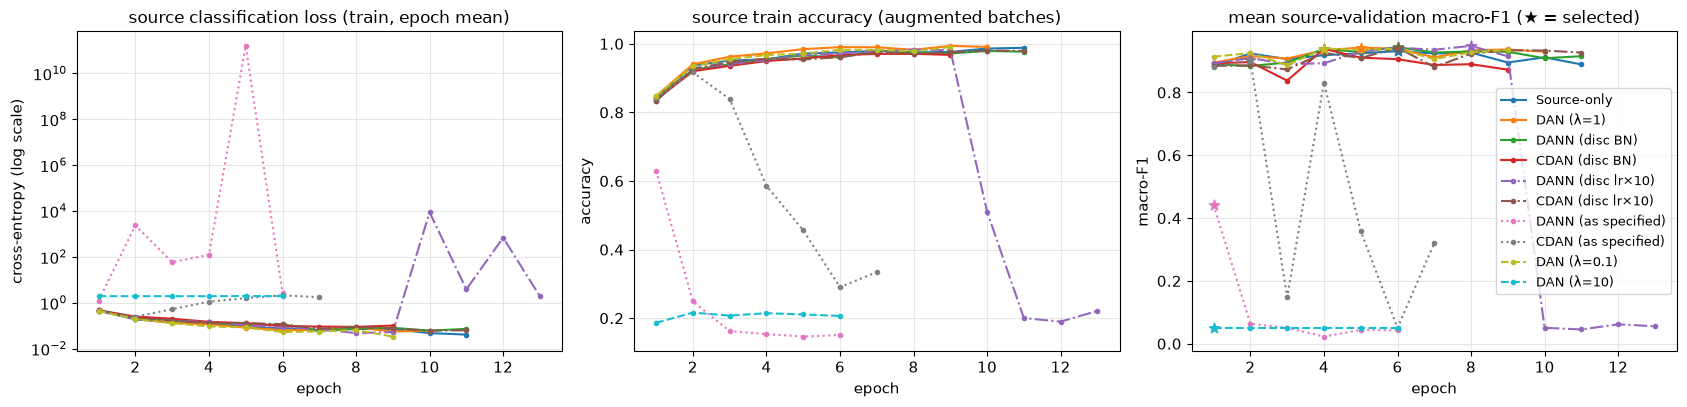

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for n in ALL_RUNS:
    ep = [h["epoch"] for h in HIST[n]]
    ls = "--" if n in ("dan_lambda0.1", "dan_lambda10") else (":" if n in AS_SPECIFIED_ADV else ("-." if n in DISCLR10_ADV else "-"))
    axes[0].plot(ep, [h["train"]["cls_loss"] for h in HIST[n]], ls, marker=".", label=LABEL[n])
    axes[1].plot(ep, [h["train"]["train_acc"] for h in HIST[n]], ls, marker=".", label=LABEL[n])
    axes[2].plot(ep, [h["val"]["mean_macro_f1"] for h in HIST[n]], ls, marker=".", label=LABEL[n])
    axes[2].scatter([SUMM[n]["best_epoch"]], [SUMM[n]["best_mean_val_macro_f1"]], s=60, marker="*", zorder=5)
for ax, t in zip(axes, ["source classification loss (train, epoch mean)", "source train accuracy (augmented batches)",
                        "mean source-validation macro-F1 (★ = selected)"]):
    ax.set_title(t); ax.set_xlabel("epoch"); ax.grid(alpha=.3)
axes[0].set_yscale("log"); axes[0].set_ylabel("cross-entropy (log scale)"); axes[1].set_ylabel("accuracy"); axes[2].set_ylabel("macro-F1")
axes[2].legend()
plt.tight_layout(); savefig(fig, "task2_training_curves"); plt.show()

saved figure task2_alignment_losses


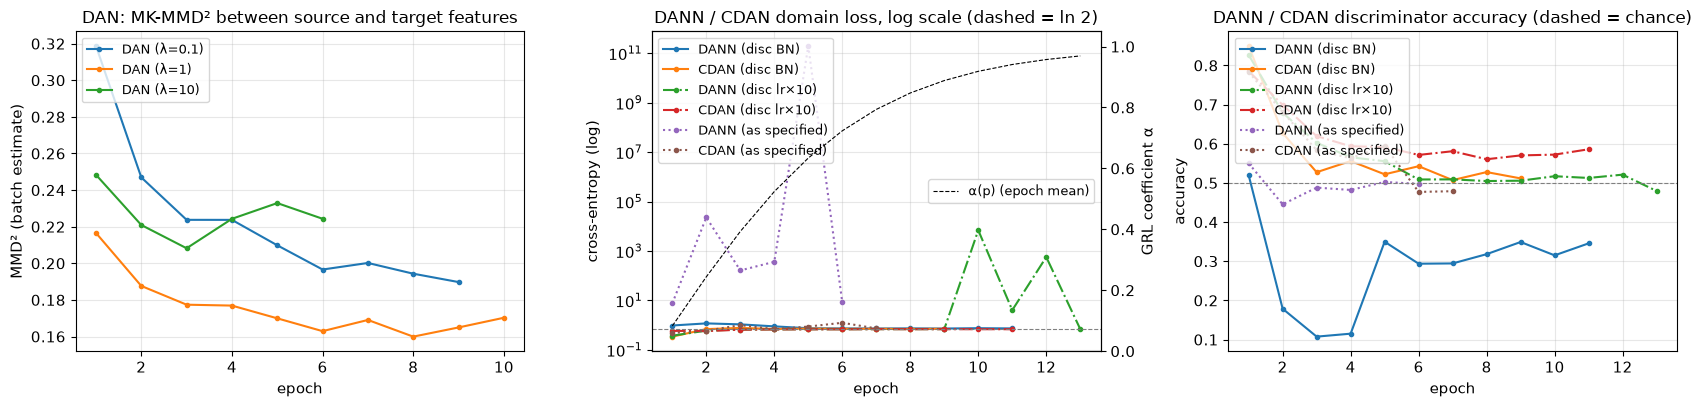

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for n in STUDY_RUNS:
    axes[0].plot([h["epoch"] for h in HIST[n]], [h["train"]["mmd"] for h in HIST[n]], marker=".", label=LABEL[n])
for n in ADV_RUNS:
    ep = [h["epoch"] for h in HIST[n]]
    ls = ":" if n in AS_SPECIFIED_ADV else ("-." if n in DISCLR10_ADV else "-")
    axes[1].plot(ep, [h["train"]["domain_loss"] for h in HIST[n]], ls, marker=".", label=LABEL[n])
    axes[2].plot(ep, [h["train"]["disc_acc"] for h in HIST[n]], ls, marker=".", label=LABEL[n])
axes[1].set_yscale("log")
ax2 = axes[1].twinx()
ax2.plot([h["epoch"] for h in HIST["dann_disclr10"]], [h["train"]["alpha"] for h in HIST["dann_disclr10"]], "k--", lw=.8, label="α(p) (epoch mean)")
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("GRL coefficient α"); ax2.legend(loc="center right")
axes[1].axhline(np.log(2), color="gray", lw=.8, ls="--"); axes[2].axhline(0.5, color="gray", lw=.8, ls="--")
axes[0].set_title("DAN: MK-MMD² between source and target features"); axes[0].set_ylabel("MMD² (batch estimate)")
axes[1].set_title("DANN / CDAN domain loss, log scale (dashed = ln 2)"); axes[1].set_ylabel("cross-entropy (log)")
axes[2].set_title("DANN / CDAN discriminator accuracy (dashed = chance)"); axes[2].set_ylabel("accuracy")
for ax in axes:
    ax.set_xlabel("epoch"); ax.grid(alpha=.3); ax.legend(loc="upper left")
plt.tight_layout(); savefig(fig, "task2_alignment_losses"); plt.show()

## 2.2b Adversarial training stability (source-side criteria, fixed before the stabilised runs finished)

A run is **stable** if (1) its epoch-mean domain loss stays below 2.0 (≈ 3 × ln 2) in every epoch and (2) its mean
source-validation macro-F1 never falls below 0.5 in any epoch (chance ≈ 0.14). Only source data and unlabelled
target images enter these criteria.

In [6]:
rows = []
for n in ADV_RUNS:
    dl = [h["train"]["domain_loss"] for h in HIST[n]]
    vf = [h["val"]["mean_macro_f1"] for h in HIST[n]]
    rows.append({"config": n, "method": LABEL[n], "disc_lr": SUMM[n].get("extra_module_lr"), "epochs_run": len(dl),
                 "max_epoch_domain_loss": max(dl), "min_epoch_val_macro_f1": min(vf), "best_val_macro_f1": max(vf),
                 "criterion1_domain_loss_below_2": max(dl) < 2.0, "criterion2_val_f1_never_below_0.5": min(vf) >= 0.5})
STAB = pd.DataFrame(rows)
STAB["stable"] = STAB["criterion1_domain_loss_below_2"] & STAB["criterion2_val_f1_never_below_0.5"]
STAB.to_csv(TAB / "task2_adversarial_stability.csv", index=False)
STAB.round(4)

,config,method,disc_lr,epochs_run,max_epoch_domain_loss,min_epoch_val_macro_f1,best_val_macro_f1,criterion1_domain_loss_below_2,criterion2_val_f1_never_below_0.5,stable
0,dann_discbn,DANN (disc BN),0.0001,11,1.184600e+00,0.8844,0.9443,True,True,True
1,cdan_discbn,CDAN (disc BN),0.0001,9,7.777000e-01,0.8378,0.9391,True,True,True
2,dann_disclr10,DANN (disc lr×10),0.0010,13,6.951308e+03,0.0454,0.9484,False,False,False
3,cdan_disclr10,CDAN (disc lr×10),0.0010,11,6.933000e-01,0.8736,0.9428,True,True,True
4,dann,DANN (as specified),0.0001,6,1.989422e+11,0.0226,0.4418,False,False,False
5,cdan,CDAN (as specified),NaN,7,1.254300e+00,0.0507,0.9026,True,False,False


## 2.3 Features, domain separability and unlabelled target predictions

In [7]:
source = proto.load_source_data()
target_images = pacs.load_target_images()
sep_cfg = load_config(CFG_DIR, "source_only")["evaluation"]["separability"]
OUT, SEP = {}, {}
for n in ALL_RUNS:
    cfg = load_config(CFG_DIR, n)
    ck = torch.load(CKPT / RUN_NAME[n] / "best.pt", map_location="cpu", weights_only=False)
    model = build_model(cfg["model"]["num_classes"], cfg["seed"])
    model.load_state_dict(ck["model"])
    model.to(DEVICE).eval()
    f_val = torch.cat([predict(model, source["val"][d][0], DEVICE)[0] for d in pacs.SOURCE_DOMAINS])
    f_tgt, z_tgt = predict(model, target_images, DEVICE)
    SEP[n] = domain_separability({"source_val": f_val.numpy(), "target": f_tgt.numpy()}, seed=SEED,
                                 test_size=sep_cfg["test_size"], C=sep_cfg["C"])
    OUT[n] = {"target_logits": z_tgt, "checkpoint_epoch": ck["epoch"]}
    print(f"{n:14s} separability {SEP[n]['separability_acc']:.4f}  (n per group {SEP[n]['n_per_group']}, "
          f"lbfgs iters {SEP[n]['lbfgs_iterations']})")
    del model
torch.save({"runs": OUT, "n_target": len(target_images)}, CACHE / "target_outputs.pt")

source_only    separability 0.9973  (n per group 1213, lbfgs iters 55)


dan            separability 0.8516  (n per group 1213, lbfgs iters 219)


dann_discbn    separability 1.0000  (n per group 1213, lbfgs iters 39)


cdan_discbn    separability 0.9973  (n per group 1213, lbfgs iters 53)


dann_disclr10  separability 0.9890  (n per group 1213, lbfgs iters 168)


cdan_disclr10  separability 0.9904  (n per group 1213, lbfgs iters 351)


dann           separability 0.9973  (n per group 1213, lbfgs iters 133)


cdan           separability 0.9973  (n per group 1213, lbfgs iters 66)


dan_lambda0.1  separability 0.9643  (n per group 1213, lbfgs iters 172)


dan_lambda10   separability 0.6538  (n per group 1213, lbfgs iters 78)


saved figure task2_domain_separability


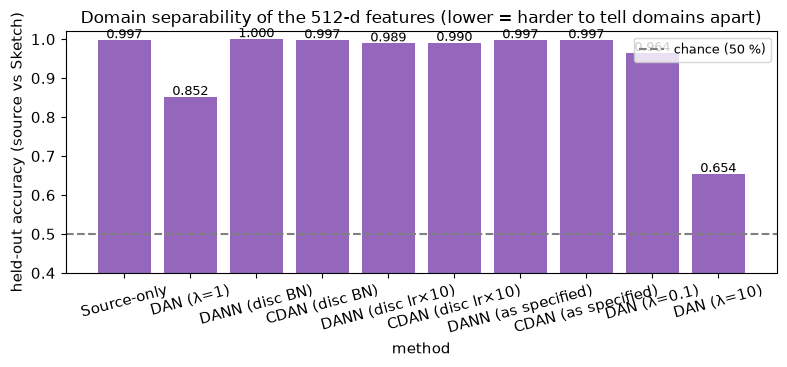

,method,separability_acc,n_per_group,lbfgs_iterations,converged
0,Source-only,0.997253,1213,55,True
1,DAN (λ=1),0.851648,1213,219,True
2,DANN (disc BN),1.000000,1213,39,True
3,CDAN (disc BN),0.997253,1213,53,True
4,DANN (disc lr×10),0.989011,1213,168,True
5,CDAN (disc lr×10),0.990385,1213,351,True
6,DANN (as specified),0.997253,1213,133,True
7,CDAN (as specified),0.997253,1213,66,True
8,DAN (λ=0.1),0.964286,1213,172,True
9,DAN (λ=10),0.653846,1213,78,True


In [8]:
SEP_TABLE = pd.DataFrame([{"config": n, "method": LABEL[n], **{k: v for k, v in SEP[n].items() if k != "test_confusion"},
                           "test_confusion": json.dumps(SEP[n]["test_confusion"])} for n in ALL_RUNS])
SEP_TABLE.to_csv(TAB / "task2_domain_separability.csv", index=False)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar([LABEL[n] for n in ALL_RUNS], [SEP[n]["separability_acc"] for n in ALL_RUNS], color="tab:purple")
ax.axhline(0.5, color="gray", ls="--", label="chance (50 %)")
for i, n in enumerate(ALL_RUNS):
    ax.text(i, SEP[n]["separability_acc"] + 0.005, f"{SEP[n]['separability_acc']:.3f}", ha="center", fontsize=9)
ax.set_ylim(0.4, 1.02); ax.set_ylabel("held-out accuracy (source vs Sketch)"); ax.set_xlabel("method")
ax.set_title("Domain separability of the 512-d features (lower = harder to tell domains apart)")
ax.legend(); plt.xticks(rotation=15); plt.tight_layout(); savefig(fig, "task2_domain_separability"); plt.show()
SEP_TABLE[["method", "separability_acc", "n_per_group", "lbfgs_iterations", "converged"]]

## 2.4 Freeze manifest

After this cell, every checkpoint, config and target prediction is fixed. Notebook 03 verifies these hashes
before it is allowed to read Sketch labels; changing any of these files afterwards makes the label loader refuse.

In [9]:
frozen = [proto.SPLIT_PATH, CACHE / "target_outputs.pt"]
for n in ALL_RUNS:
    frozen += [CKPT / RUN_NAME[n] / f for f in ("best.pt", "config.yaml", "summary.json")]
manifest = pacs.write_freeze_manifest(CACHE / "freeze_manifest.json", frozen,
                                      note="Task 2: all runs trained, checkpoints selected on source validation, target predictions computed")
print("frozen files:", len(manifest["files"]), "| created", manifest["created"])

frozen files: 32 | created 2026-09-22 17:34:21
